Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [2]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# For reproducibility (optional)
torch.manual_seed(42)
np.random.seed(42)

GAN Hyperparameters

In [3]:
IMG_SIZE = 64
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
TRAIN_DIR = '/content/drive/MyDrive/train'
TEST_DIR  = '/content/drive/MyDrive/test'

In [5]:
print("Device:", DEVICE)

Device: cuda


Transforms and DataLoader

In [29]:
label_map = {
    "happy": 1,
    "sad": 0,
    "angry": 0
}

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


Custom Dataset for FER2013 (only positive & negative)

In [7]:
class CustomFERDataset(Dataset):
    def __init__(self, img_dir, label_map, transform=None):
        self.transform = transform
        self.img_paths = []
        self.labels = []

        for label_name, label_val in label_map.items():
            class_dir = os.path.join(img_dir, label_name)
            if not os.path.isdir(class_dir):
                continue
            for img_file in glob.glob(os.path.join(class_dir, "*.jpg")) + glob.glob(os.path.join(class_dir, "*.png")):
                self.img_paths.append(img_file)
                self.labels.append(label_val)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('L')  # 'L' -> grayscale
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [8]:
# Quick check for directories (adjust paths if needed)
print("Train directory exists:", os.path.exists(TRAIN_DIR))
if os.path.exists(TRAIN_DIR):
    print("Train subfolders:", [d for d in os.listdir(TRAIN_DIR)])

Train directory exists: True
Train subfolders: ['fear', 'neutral', 'surprise', 'sad', 'disgust', 'happy', 'angry']


DataLoaders

In [9]:
# Create datasets; if folders not present this will create empty datasets
train_dataset = CustomFERDataset(TRAIN_DIR, label_map, transform)
test_dataset  = CustomFERDataset(TEST_DIR, label_map, transform)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# sanity
if len(train_dataset) > 0:
    imgs, _ = next(iter(train_loader))
    print("Batch shape (B,C,H,W):", imgs.shape)
else:
    print("Train dataset is empty. Check TRAIN_DIR path and image files.")

Batch shape (B,C,H,W): torch.Size([100, 1, 64, 64])


DCGAN Generator

In [10]:
class DCGANGenerator(nn.Module):
    """
    Expects input z of shape (batch, LATENT_DIM, 1, 1)
    Produces output (batch, 1, IMG_SIZE, IMG_SIZE)
    """
    def __init__(self, latent_dim, img_channels=1, feature_maps=64):
        super(DCGANGenerator, self).__init__()
        self.model = nn.Sequential(
            # input: (batch, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, feature_maps * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        return self.model(z)


DCGAN Discriminator

In [11]:
class DCGANDiscriminator(nn.Module):
    """
    Input images shape: (batch, 1, IMG_SIZE, IMG_SIZE)
    Output: single probability per image (batch, 1)
    """
    def __init__(self, img_channels=1, feature_maps=64):
        super(DCGANDiscriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # final conv to scalar output
            nn.Conv2d(feature_maps * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)          # shape (batch, 1, 1, 1)
        return out.view(-1, 1)         # shape (batch, 1)

Instantiate DCGAN models, loss, optimizers

In [12]:
latent_dim = LATENT_DIM  # be consistent

gen = DCGANGenerator(latent_dim=latent_dim, img_channels=1).to(DEVICE)
disc = DCGANDiscriminator(img_channels=1).to(DEVICE)

criterion_gan = nn.BCELoss()
optimizer_G = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

Utility: show generated images

In [13]:
def show_generated_images(generator, n_images=25, latent_dim=LATENT_DIM, device=DEVICE):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, 1, 1, device=device)
        gen_imgs = generator(z)              # (n_images, 1, H, W)
        # Denormalize from [-1,1] to [0,1] when normalize=True in make_grid will handle it,
        grid = make_grid(gen_imgs.cpu(), nrow=5, normalize=True)
        plt.figure(figsize=(6,6))
        plt.axis("off")
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.show()

DCGAN Training loop

[Epoch 1/50] D Loss: 0.0491 | G Loss: 11.7483
[Epoch 2/50] D Loss: 0.0825 | G Loss: 7.2643


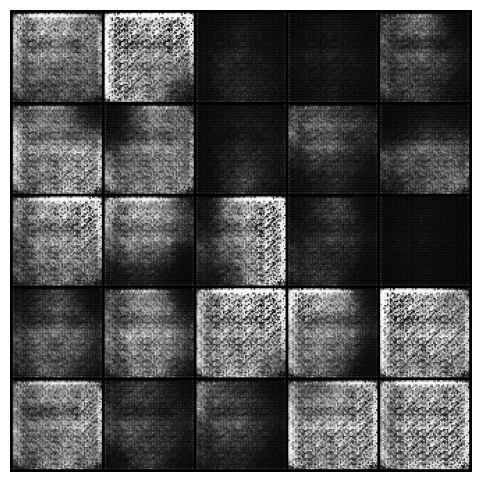

[Epoch 3/50] D Loss: 0.1383 | G Loss: 5.8265
[Epoch 4/50] D Loss: 0.1001 | G Loss: 6.0572


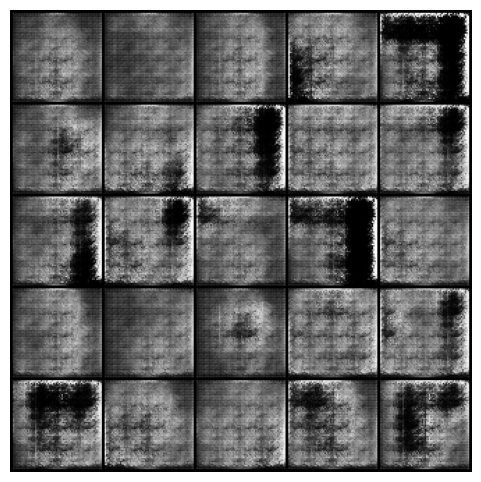

[Epoch 5/50] D Loss: 0.0684 | G Loss: 7.1217
[Epoch 6/50] D Loss: 0.1138 | G Loss: 5.5843


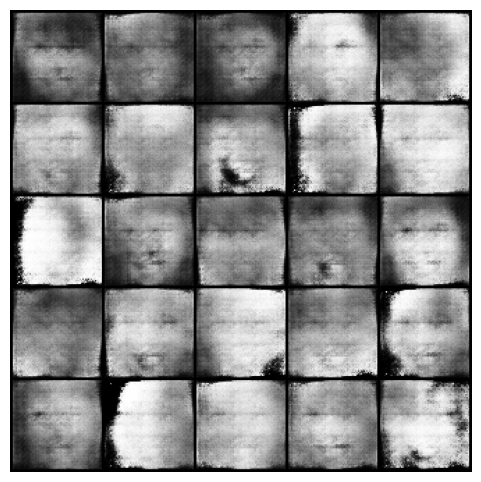

[Epoch 7/50] D Loss: 0.1193 | G Loss: 5.6496
[Epoch 8/50] D Loss: 0.1620 | G Loss: 5.5904


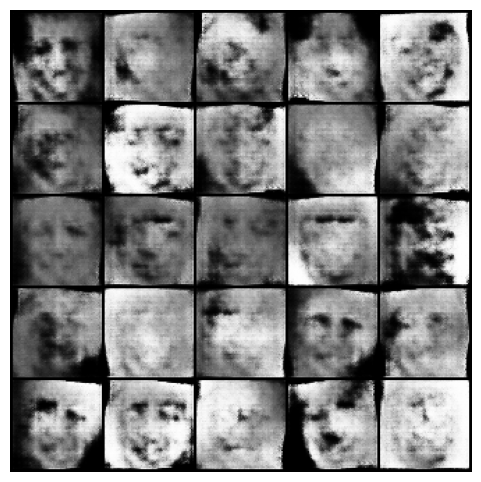

[Epoch 9/50] D Loss: 0.1640 | G Loss: 5.5045
[Epoch 10/50] D Loss: 0.1308 | G Loss: 5.0331


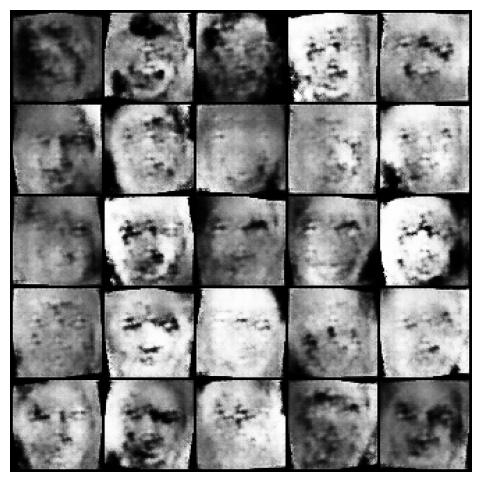

[Epoch 11/50] D Loss: 0.1555 | G Loss: 4.9371
[Epoch 12/50] D Loss: 0.1594 | G Loss: 4.8959


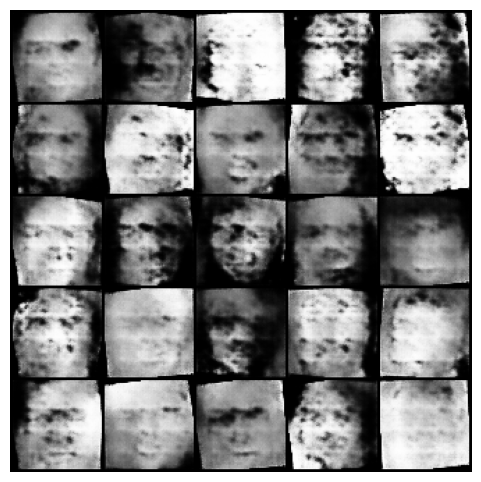

[Epoch 13/50] D Loss: 0.1624 | G Loss: 4.9379
[Epoch 14/50] D Loss: 0.0788 | G Loss: 6.1027


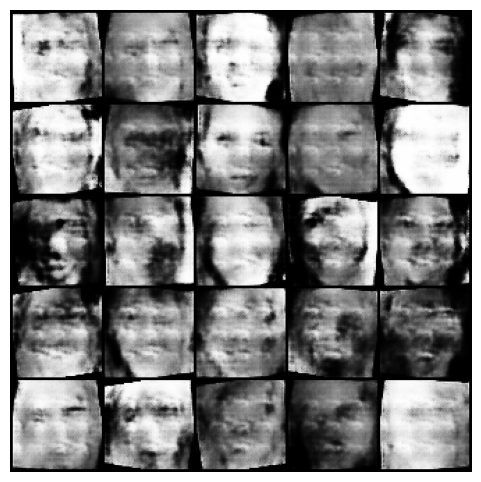

[Epoch 15/50] D Loss: 0.1605 | G Loss: 5.6509
[Epoch 16/50] D Loss: 0.1778 | G Loss: 5.5650


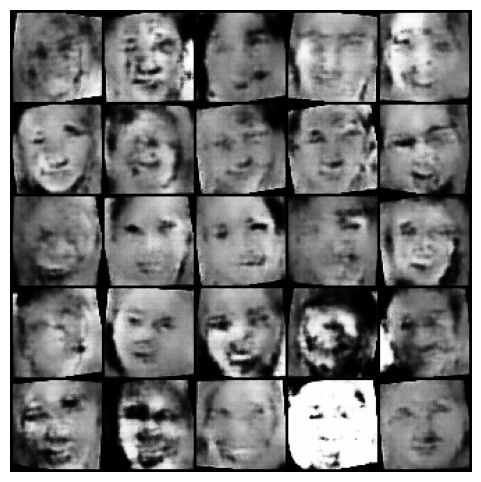

[Epoch 17/50] D Loss: 0.1204 | G Loss: 6.4001
[Epoch 18/50] D Loss: 0.1147 | G Loss: 5.1638


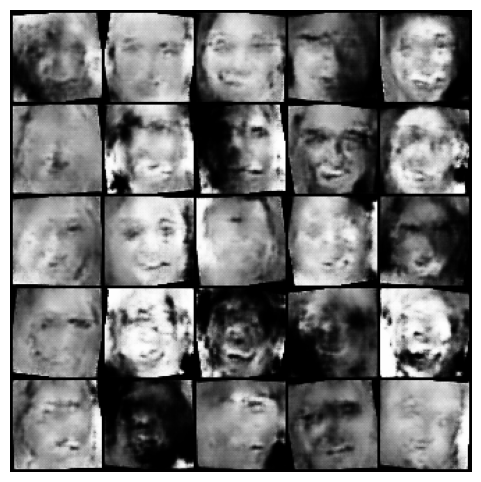

[Epoch 19/50] D Loss: 0.1428 | G Loss: 5.0726
[Epoch 20/50] D Loss: 0.1495 | G Loss: 4.4896


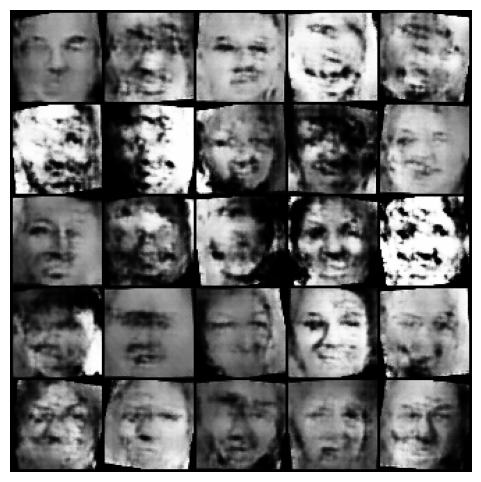

[Epoch 21/50] D Loss: 0.1176 | G Loss: 4.7271
[Epoch 22/50] D Loss: 0.1546 | G Loss: 4.7756


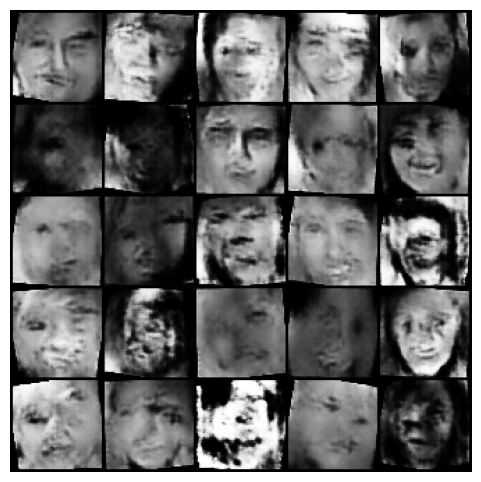

[Epoch 23/50] D Loss: 0.0958 | G Loss: 5.9463
[Epoch 24/50] D Loss: 0.1456 | G Loss: 5.8032


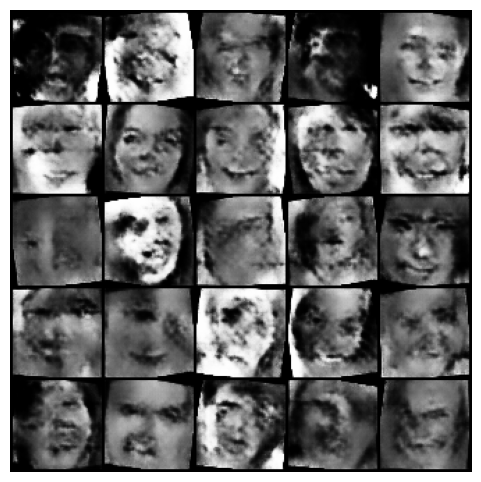

[Epoch 25/50] D Loss: 0.1230 | G Loss: 5.5000
[Epoch 26/50] D Loss: 0.0624 | G Loss: 6.1392


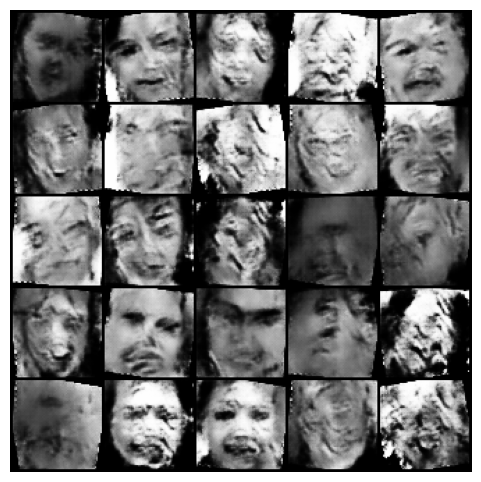

[Epoch 27/50] D Loss: 0.1466 | G Loss: 4.7834
[Epoch 28/50] D Loss: 0.1106 | G Loss: 5.8182


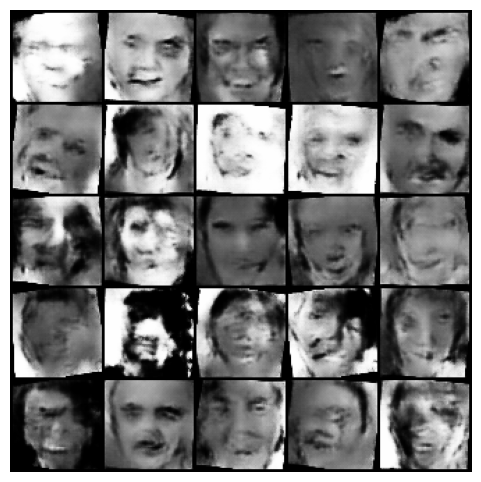

[Epoch 29/50] D Loss: 0.1003 | G Loss: 5.6917
[Epoch 30/50] D Loss: 0.0940 | G Loss: 6.0738


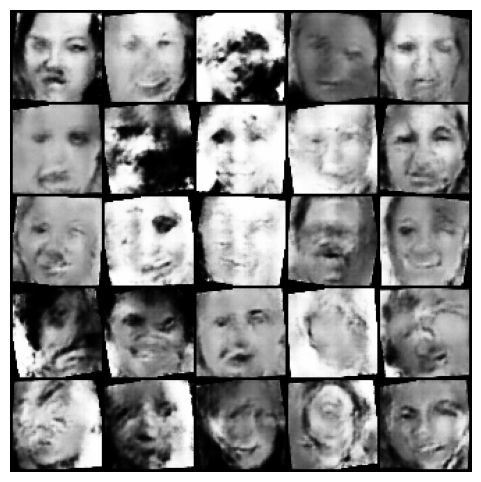

[Epoch 31/50] D Loss: 0.0884 | G Loss: 5.5689
[Epoch 32/50] D Loss: 0.0841 | G Loss: 5.8615


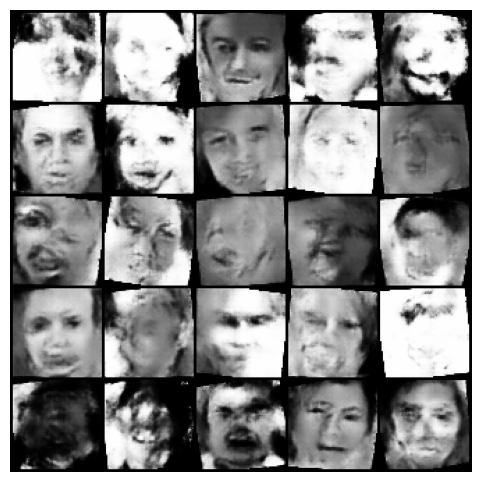

[Epoch 33/50] D Loss: 0.1441 | G Loss: 5.6930
[Epoch 34/50] D Loss: 0.0699 | G Loss: 5.7508


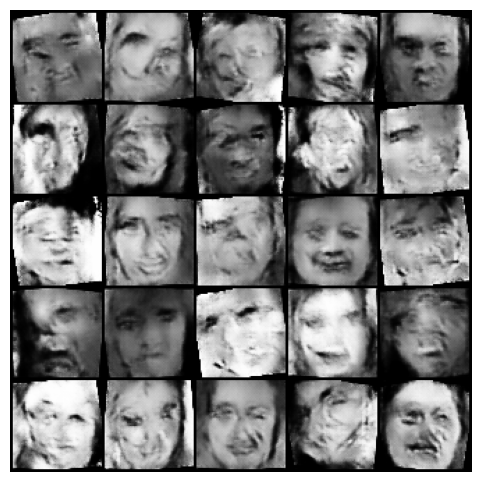

[Epoch 35/50] D Loss: 0.1207 | G Loss: 5.9384
[Epoch 36/50] D Loss: 0.0929 | G Loss: 5.9115


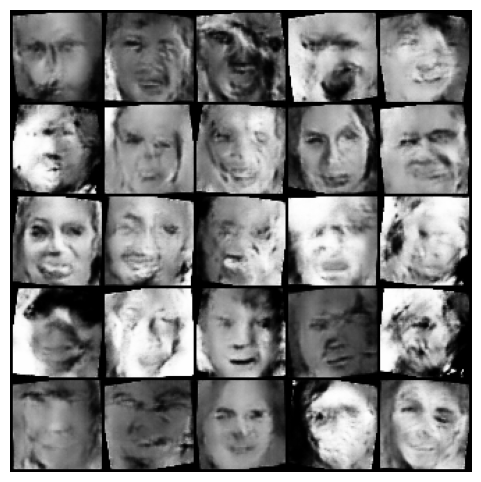

[Epoch 37/50] D Loss: 0.0473 | G Loss: 6.0107
[Epoch 38/50] D Loss: 0.1237 | G Loss: 6.0258


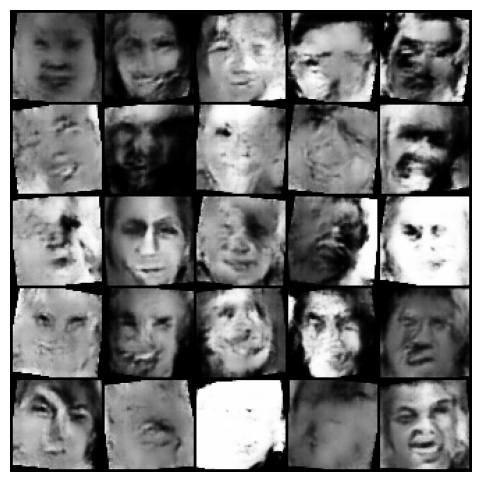

[Epoch 39/50] D Loss: 0.1308 | G Loss: 4.5371
[Epoch 40/50] D Loss: 0.0715 | G Loss: 5.5049


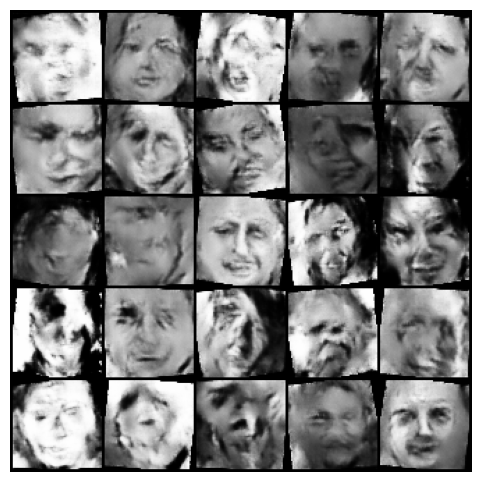

[Epoch 41/50] D Loss: 0.0941 | G Loss: 5.6054
[Epoch 42/50] D Loss: 0.0825 | G Loss: 5.9485


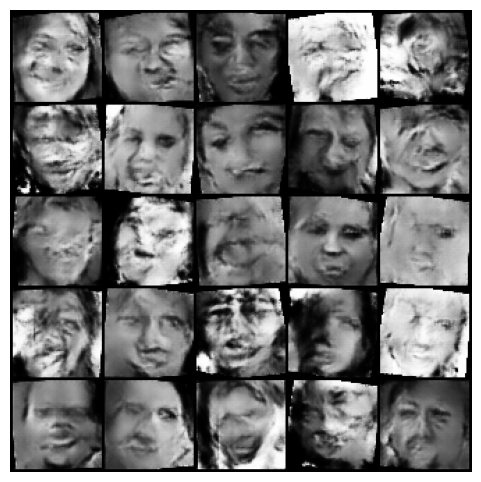

[Epoch 43/50] D Loss: 0.0874 | G Loss: 6.0063
[Epoch 44/50] D Loss: 0.0892 | G Loss: 5.8494


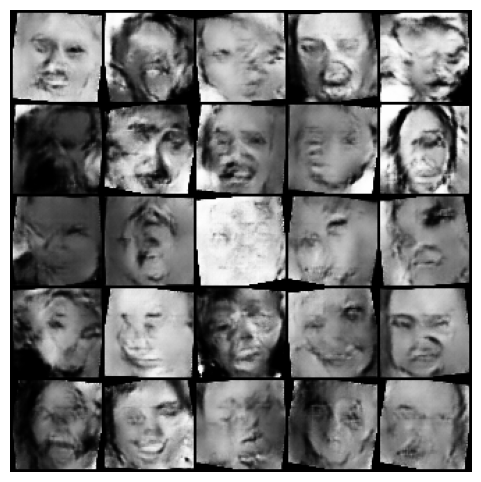

[Epoch 45/50] D Loss: 0.0570 | G Loss: 6.4635
[Epoch 46/50] D Loss: 0.0947 | G Loss: 5.5057


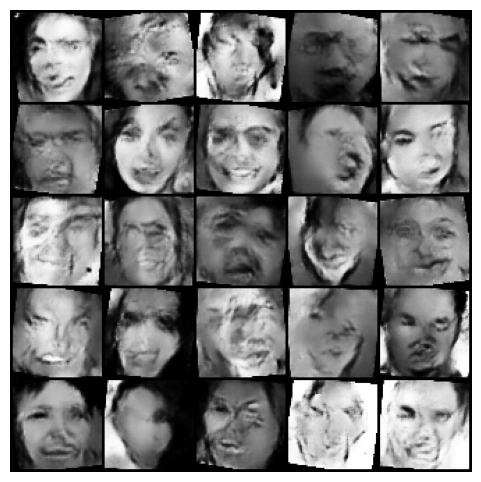

[Epoch 47/50] D Loss: 0.0668 | G Loss: 6.3460
[Epoch 48/50] D Loss: 0.0876 | G Loss: 6.1516


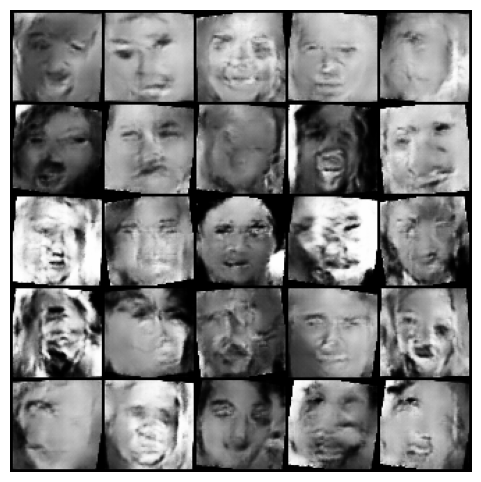

[Epoch 49/50] D Loss: 0.0332 | G Loss: 6.8029
[Epoch 50/50] D Loss: 0.0811 | G Loss: 6.5924


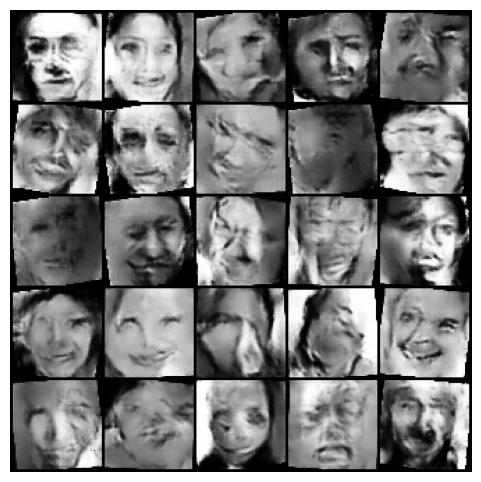

In [14]:
for epoch in range(EPOCHS):
    gen.train()
    disc.train()
    running_d_loss = 0.0
    running_g_loss = 0.0

    for batch_index, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(DEVICE)
        batch_size = imgs.size(0)

        real_labels = torch.ones(batch_size, 1, device=DEVICE)
        fake_labels = torch.zeros(batch_size, 1, device=DEVICE)

        # ----- Train Discriminator -----
        optimizer_D.zero_grad()

        outputs_real = disc(imgs)
        loss_real = criterion_gan(outputs_real, real_labels)

        z = torch.randn(batch_size, latent_dim, 1, 1, device=DEVICE)
        fake_imgs = gen(z)
        outputs_fake = disc(fake_imgs.detach())
        loss_fake = criterion_gan(outputs_fake, fake_labels)

        d_loss = (loss_real + loss_fake) * 0.5
        d_loss.backward()
        optimizer_D.step()

        running_d_loss += d_loss.item()

        # ----- Train Generator (half frequency = faster) -----
        if batch_index % 2 == 0:
            optimizer_G.zero_grad()
            outputs_generated = disc(fake_imgs)
            g_loss = criterion_gan(outputs_generated, real_labels)
            g_loss.backward()
            optimizer_G.step()
            running_g_loss += g_loss.item()

    print(f"[Epoch {epoch+1}/{EPOCHS}] D Loss: {running_d_loss/len(train_loader):.4f} | "
          f"G Loss: {running_g_loss/max(1,(len(train_loader)//2)):.4f}")

    if (epoch + 1) % 2 == 0:
        show_generated_images(gen, 25)


Emotion classifier (CNN) definition

In [15]:
class EmotionClassifier(nn.Module):
    def __init__(self):
        super(EmotionClassifier, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # After 3 pools with starting IMAGE_SIZE=64 -> 64/2/2/2 = 8
        self.fc = nn.Sequential(
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

Train emotion classifier

In [16]:
device = DEVICE
model = EmotionClassifier().to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs_cls = 10  # increase for better performance

train_losses = [] # Initialize list to store training losses

for epoch in range(num_epochs_cls):
    model.train()
    running_loss = 0.0
    total_batches = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_batches += 1

    avg_loss = running_loss / max(1, total_batches)
    train_losses.append(avg_loss) # Store the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs_cls}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 0.6640
Epoch 2/10, Loss: 0.5784
Epoch 3/10, Loss: 0.5005
Epoch 4/10, Loss: 0.4492
Epoch 5/10, Loss: 0.4158
Epoch 6/10, Loss: 0.3925
Epoch 7/10, Loss: 0.3780
Epoch 8/10, Loss: 0.3680
Epoch 9/10, Loss: 0.3524
Epoch 10/10, Loss: 0.3455


In [17]:
class EmotionClassifier(nn.Module):
    def __init__(self):
        super(EmotionClassifier, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # After 3 pools with starting IMAGE_SIZE=64 -> 64/2/2/2 = 8
        self.fc = nn.Sequential(
            nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [18]:
device = DEVICE
model = EmotionClassifier().to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs_cls = 10  # increase for better performance

train_losses = [] # Initialize list to store training losses

for epoch in range(num_epochs_cls):
    model.train()
    running_loss = 0.0
    total_batches = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_batches += 1

    avg_loss = running_loss / max(1, total_batches)
    train_losses.append(avg_loss) # Store the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs_cls}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 0.6101
Epoch 2/10, Loss: 0.4617
Epoch 3/10, Loss: 0.3970
Epoch 4/10, Loss: 0.3601
Epoch 5/10, Loss: 0.3388
Epoch 6/10, Loss: 0.3181
Epoch 7/10, Loss: 0.3053
Epoch 8/10, Loss: 0.2930
Epoch 9/10, Loss: 0.2796
Epoch 10/10, Loss: 0.2691


Evaluate classifier

In [19]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        preds = (outputs > 0.5).long().view(-1)
        labels = labels.long().view(-1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

if total > 0:
    print(f"Test Accuracy: {100.0 * correct / total:.2f}%  ({correct}/{total})")
else:
    print("Test dataset empty or path incorrect.")

Test Accuracy: 88.31%  (3514/3979)


Predict & show a single image

In [20]:
def predict_and_show(model, image_path, device=DEVICE):
    model.eval()
    img_color = Image.open(image_path).convert("RGB")
    img_gray = img_color.convert("L")

    transform_input = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    img_tensor = transform_input(img_gray).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = "positive" if output.item() > 0.5 else "negative"

    plt.imshow(img_color)
    plt.title(f"Predicted: {pred}")
    plt.axis("off")
    plt.show()

Predict Sentiment for a Custom Input Image

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torch

def predict_and_show(image_path):
    model.eval()

    try:
        # Load original image
        img_color = Image.open(image_path).convert("RGB")
    except:
        print(f"❌ ERROR: Cannot load image at: {image_path}")
        return

    # Convert to grayscale for the model
    img_gray = img_color.convert("L")

    # Same preprocessing as training
    transform_input = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Preprocess
    img_tensor = transform_input(img_gray).unsqueeze(0).to(DEVICE)

    # Predict
    with torch.no_grad():
        output = model(img_tensor)
        prob = output.item()
        pred = "positive" if prob > 0.5 else "negative"

    # Show image + prediction
    plt.figure(figsize=(4,4))
    plt.imshow(img_color)
    plt.title(f"Predicted Sentiment: {pred}\nConfidence: {prob:.4f}")
    plt.axis("off")
    plt.show()

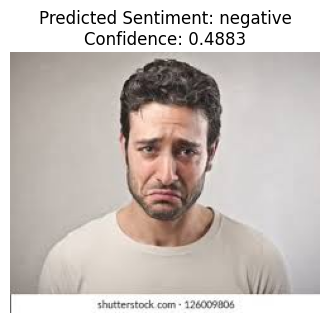

In [26]:
predict_and_show("/content/sadd.jpeg")

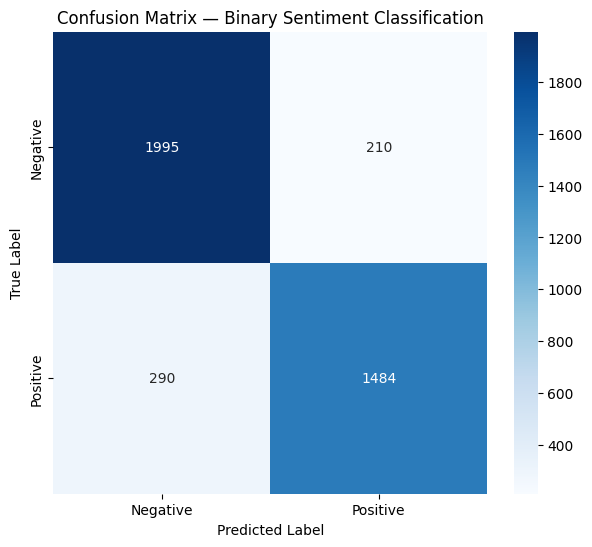


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.90      0.89      2205
    Positive       0.88      0.84      0.86      1774

    accuracy                           0.87      3979
   macro avg       0.87      0.87      0.87      3979
weighted avg       0.87      0.87      0.87      3979



In [27]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Model is binary: 0 for negative (sad/angry), 1 for positive (happy)
class_names = ["Negative", "Positive"]

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(imgs)
        # Convert probabilities to binary predictions (0 or 1)
        preds = (outputs > 0.5).long().view(-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ----------------- Confusion Matrix -----------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Binary Sentiment Classification")
plt.show()

# ---------------- Classification Report ----------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

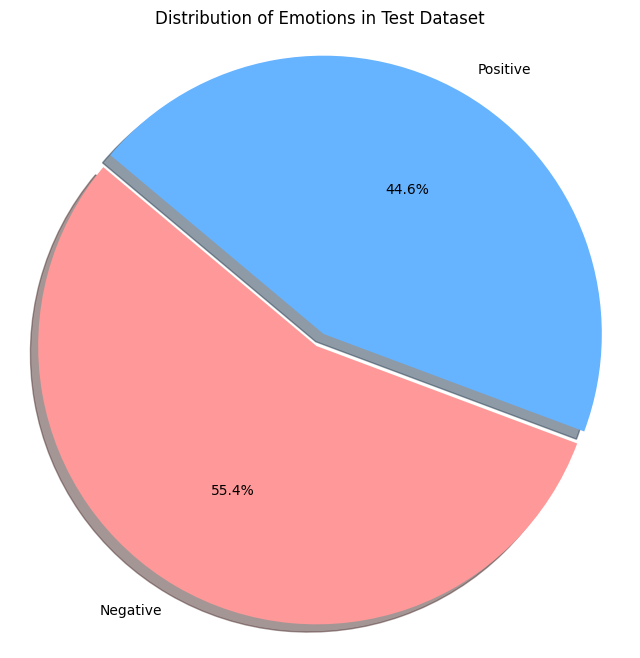

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming all_labels and class_names are available from the previous classification report cell
# If not, you might need to re-run the classification report cell (6gAlt-ZkAvro)

# Get counts for each class
negative_count = np.sum(all_labels == 0)
positive_count = np.sum(all_labels == 1)

counts = [negative_count, positive_count]
labels = [class_names[0], class_names[1]] # 'Negative', 'Positive'
colors = ['#ff9999','#66b3ff'] # Pastel colors for the pie chart
explode = (0.05, 0) # slightly explode the 'Negative' slice for emphasis

plt.figure(figsize=(8, 8))
plt.pie(counts, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Emotions in Test Dataset')
plt.show()

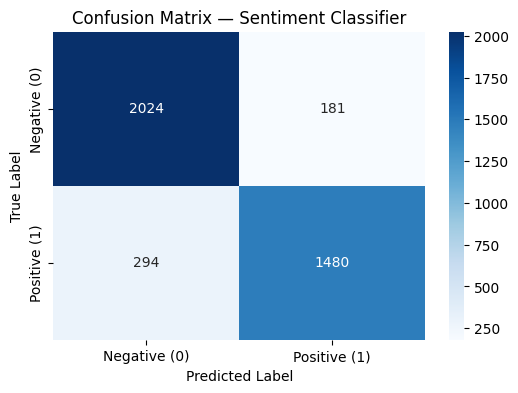


Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.92      0.89      2205
    Positive       0.89      0.83      0.86      1774

    accuracy                           0.88      3979
   macro avg       0.88      0.88      0.88      3979
weighted avg       0.88      0.88      0.88      3979



In [23]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Compute predictions on test set ----
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(imgs)
        preds = (outputs > 0.5).long().view(-1).cpu().numpy()
        labels = labels.long().view(-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative (0)", "Positive (1)"],
            yticklabels=["Negative (0)", "Positive (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Sentiment Classifier")
plt.show()

# ---- Optional: Detailed classification report ----
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

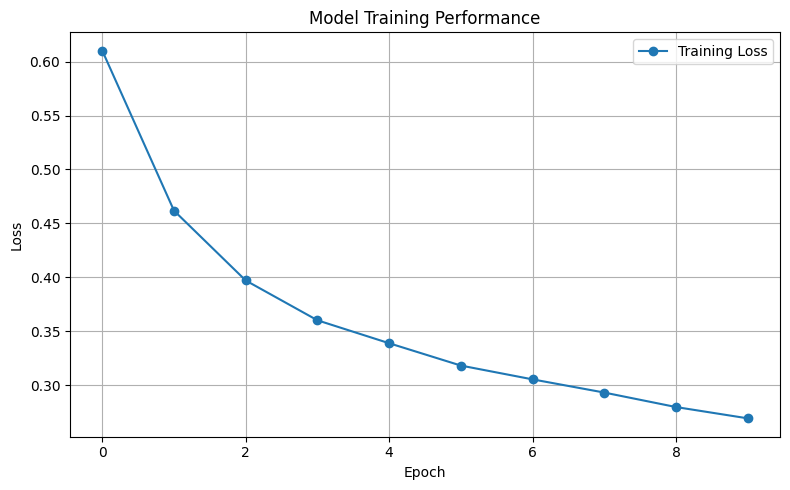

In [25]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

# Plot training loss
plt.plot(train_losses, label="Training Loss", marker='o')

# If validation loss exists, plot it too
if 'val_losses' in globals() and len(val_losses) > 0:
    plt.plot(val_losses, label="Validation Loss", marker='s')

plt.title("Model Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()